In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import pymorphy3
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, recall_score, classification_report, roc_curve, auc, roc_auc_score
from tqdm import tqdm
tqdm.pandas()

In [2]:
df = pd.read_csv('C:/Users/igrew/OneDrive/Desktop/Course Work/Datasets/news_detector/FINAL_DATASET.csv')
df.head()

,text,label
0,Андріївка – явка з повинною окупантів: дайджес...,0
1,У біолабораторіях України проводили досліди з ...,0
2,Білл Гейтс закликав негайно прибрати з ринку у...,0
3,Королеву Єлизавету II лікують від COVID-19 «за...,0
4,Вакцини проти COVID-19 збільшили дитячу смертн...,0


In [3]:
nans = df.isnull().sum()
print(f"Number of nans: \n{nans}")

df = df.dropna()
print(f"\nПісля видалення NaN: {len(df)} рядків")

Number of nans: 
text     0
label    0
dtype: int64

Після видалення NaN: 21738 рядків


In [4]:
print(df['label'].value_counts())
print(df[df['label']==1]['text'].iloc[0])  
print(df[df['label']==0]['text'].iloc[0])  

label
0    10869
1    10869
Name: count, dtype: int64
Оголошення, які поширюють на під’їздає будинків, — не повістки, а наказ про загальну мобілізацію.
Андріївка – явка з повинною окупантів: дайджест пропаганди РФ за 15 серпня


                                                text  label
0  Андріївка – явка з повинною окупантів: дайджес...      0
1  У біолабораторіях України проводили досліди з ...      0
2  Білл Гейтс закликав негайно прибрати з ринку у...      0
3  Королеву Єлизавету II лікують від COVID-19 «за...      0
4  Вакцини проти COVID-19 збільшили дитячу смертн...      0
Number of true news: 10869
Number of fake news: 10869


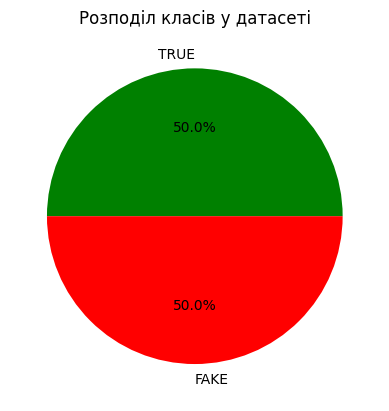

In [7]:

print(df.head())
true_count = (df['label'] == 1).sum()
fake_count = (df['label'] == 0).sum()
print(f"Number of true news: {true_count}")
print(f"Number of fake news: {fake_count}")
plt.pie([10869, 10869], labels=['TRUE', 'FAKE'], 
        autopct='%1.1f%%', colors=['green','red'])
plt.title('Розподіл класів у датасеті')
plt.savefig('dataset_distribution.png')

In [8]:
with open('C:/Users/igrew/OneDrive/Desktop/Course Work/Models/stopwords_ua.txt', 'r', encoding='utf-8') as f:
    content = f.read()
    stopwords = content.strip().split()
print(stopwords[:10])

['а', 'аби', 'абиде', 'абиким', 'абикого', 'абиколи', 'абикому', 'абикуди', 'абихто', 'абичий']


In [9]:
text = df.drop(columns='label', axis=1)

def filtering(sentence):
    clean_text = sentence.lower()
    clean_text = re.sub(r'[^\w\s]', '', clean_text)
    words = clean_text.split()
    clean_text = [word for word in words if word not in stopwords]
    return ' '.join(clean_text)
text['text'] = text['text'].progress_apply(filtering)
text

100%|██████████| 21738/21738 [00:09<00:00, 2209.97it/s]


,text
0,андріївка явка повинною окупантів дайджест про...
1,біолабораторіях україни проводили досліди коро...
2,білл гейтс закликав негайно прибрати ринку вак...
3,королеву єлизавету ii лікують covid19 забороне...
4,вакцини covid19 збільшили дитячу смертність 52...
...,...
21733,нацполіція порушила пять кримінальних провадже...
21734,території святогірської лаври краматорському р...
21735,залізничники кажуть гроші людям слід іти банкі...
21736,ватикан вперше назвав росію агресором війну ук...


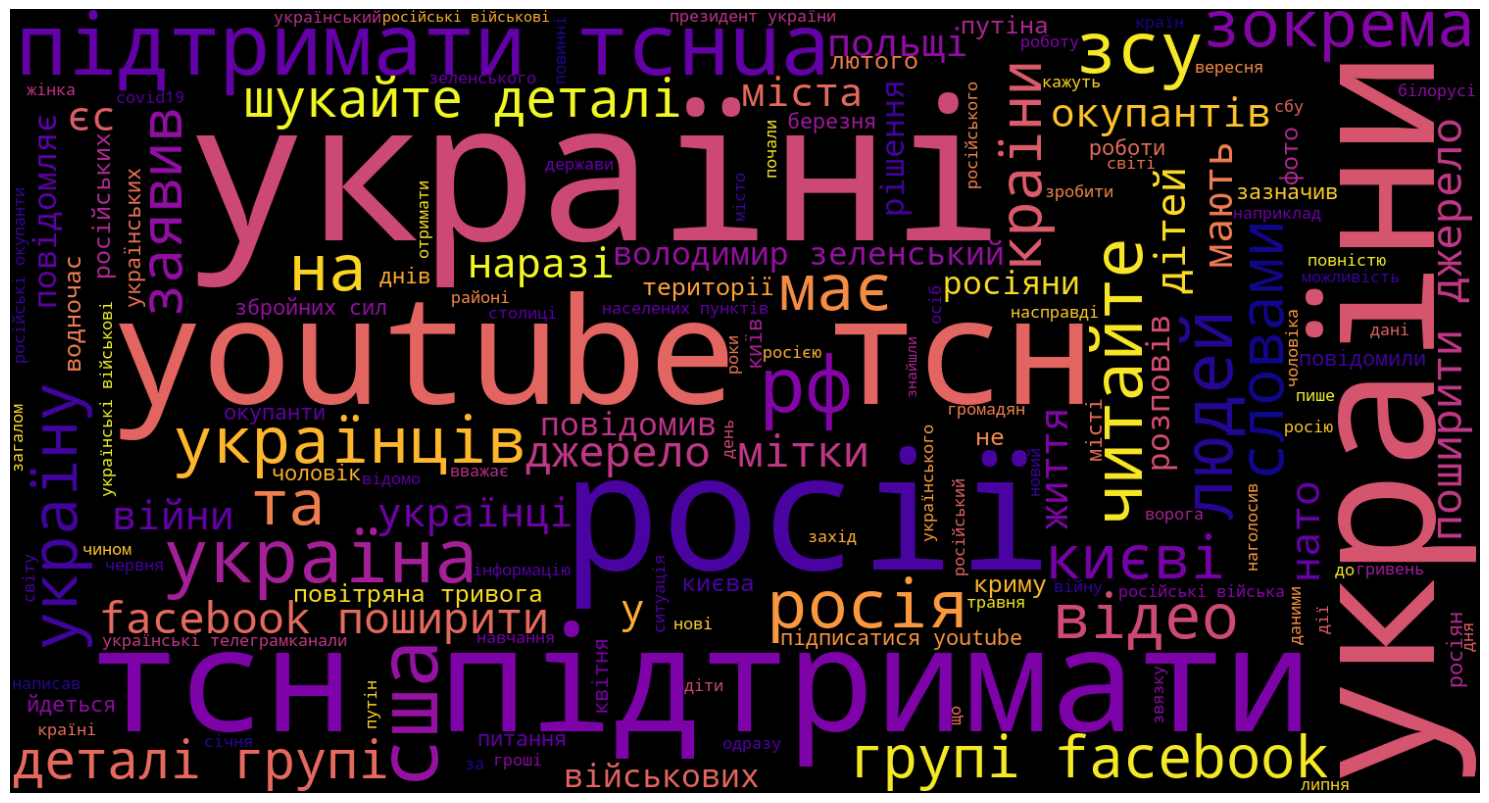

In [10]:
text_for_wordcloud = ' '.join(text['text'])
wordcloud = WordCloud(
    width=1500, 
    height=800, 
    max_words=150, 
    background_color='black',
    min_font_size=10,
    max_font_size=200,
    prefer_horizontal=0.7,
    colormap='plasma'
    )
wordcloud.generate(text_for_wordcloud)
plt.figure(figsize=(15,10))
plt.axis(False)
plt.tight_layout()
plt.imshow(wordcloud, interpolation='bilinear')


In [11]:
morph = pymorphy3.MorphAnalyzer(lang='uk')

lemma_cache = {}

def lemmatize_text(sentence):
    words = sentence.split()
    lemmas = []
    for word in words:
        if word not in lemma_cache:
            lemma_cache[word] = morph.parse(word)[0].normal_form
        lemmas.append(lemma_cache[word])
    return ' '.join(lemmas)

print(f"Before filtering: {df['text'].iloc[0]}")

text['text'] = text['text'].progress_apply(lemmatize_text)

print(f"After filtering: {text['text'].iloc[0]}")

all_words_before = ' '.join(df['text']).split()
all_words_after = ' '.join(text['text']).split()
unique_words_before_filtering = len(set(all_words_before))
unique_words_after_filtering = len(set(all_words_after))
print(f"Unique words before filtering: {unique_words_before_filtering}")
print(f"Unique words after filtering: {unique_words_after_filtering}")
decrease_percent = (unique_words_before_filtering - unique_words_after_filtering) / unique_words_before_filtering * 100
print(f"Decreased by {decrease_percent:.2f}%")

Before filtering: Андріївка – явка з повинною окупантів: дайджест пропаганди РФ за 15 серпня


100%|██████████| 21738/21738 [00:07<00:00, 3025.28it/s]


After filtering: андріївка явка повинний окупант дайджест пропаганда рф 15 серпень
Unique words before filtering: 183107
Unique words after filtering: 78508
Decreased by 57.12%


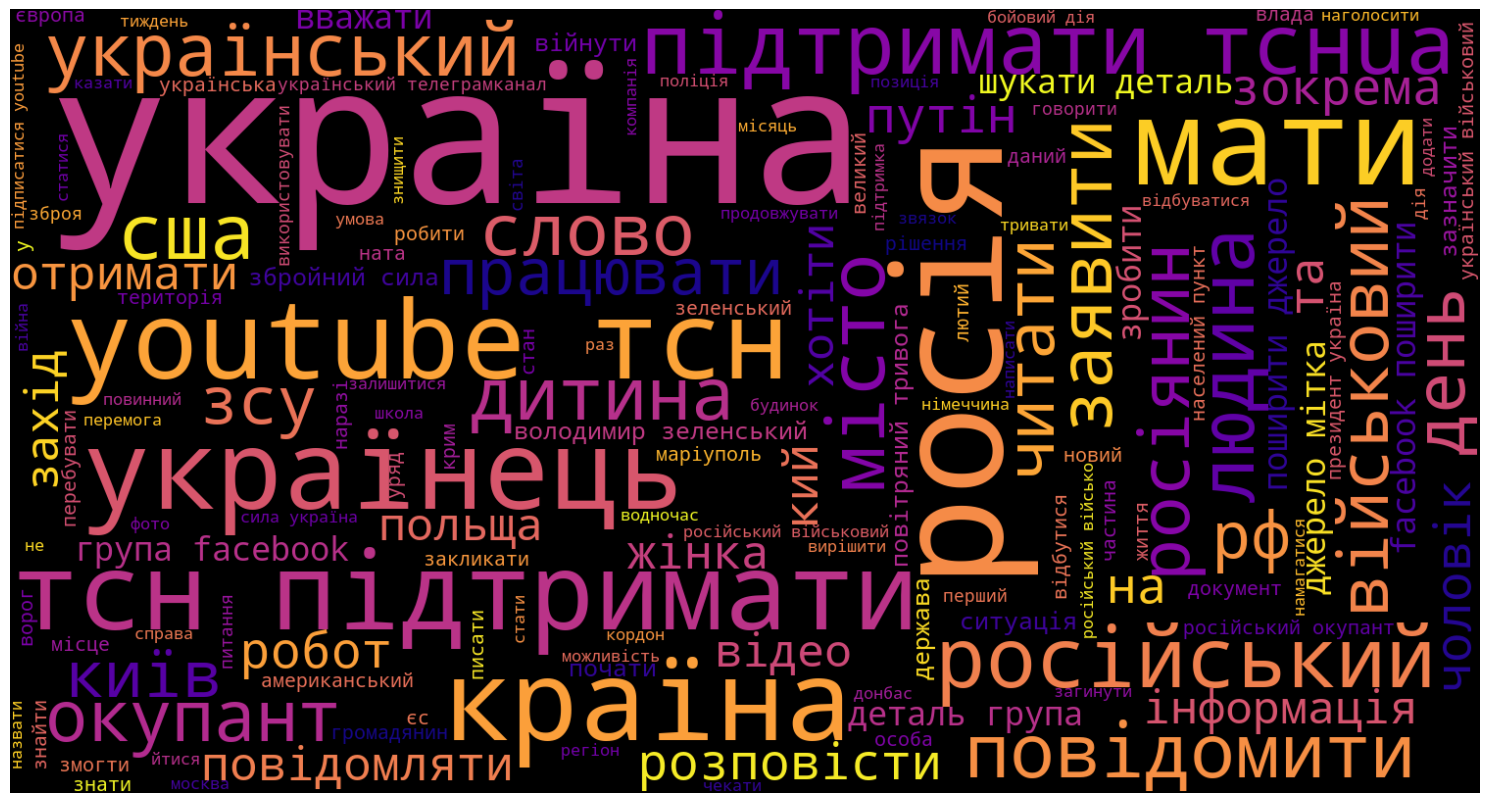

In [12]:
text_for_wordcloud = ' '.join(text['text'])
wordcloud = WordCloud(
    width=1500, 
    height=800, 
    max_words=150, 
    background_color='black',
    min_font_size=10,
    max_font_size=200,
    prefer_horizontal=0.7,
    colormap='plasma'
    )
wordcloud.generate(text_for_wordcloud)
plt.figure(figsize=(15,10))
plt.axis(False)
plt.tight_layout()
plt.imshow(wordcloud, interpolation='bilinear')
plt.savefig('wordcloud_after_lemma.png', dpi=150, bbox_inches='tight')

In [18]:
X = text['text'].values
Y = df['label'].values
print(X[:5])
print(Y[:5])

['андріївка явка повинний окупант дайджест пропаганда рф 15 серпень'
 'біолабораторія україна проводити дослід коронавірус кажан'
 'білл гейтс закликати негайно прибрати ринка вакцина covid19'
 'королевий єлизавета ii лікувати covid19 заборонений ліки'
 'вакцина covid19 збільшити дитячий смертність 52 раз']
[0 0 0 0 0]


In [19]:
print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (21738,)
Y shape: (21738,)


In [20]:
vectorizer = TfidfVectorizer(
    max_features=30000,  
    ngram_range=(1, 2), 
    min_df=2, 
    max_df=0.9, 
    sublinear_tf=True,
    use_idf=True,
    smooth_idf=True 
)

X = vectorizer.fit_transform(X)
print(f"TF-IDF векторизація завершена: {X.shape[1]} ознак")


TF-IDF векторизація завершена: 30000 ознак


In [22]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 623022 stored elements and shape (21738, 30000)>
  Coords	Values
  (0, 2806)	0.37890260754426797
  (0, 29314)	0.3582501465701116
  (0, 19195)	0.2208057268782551
  (0, 17174)	0.16062484152344403
  (0, 7405)	0.3988955536826961
  (0, 21090)	0.2590139916527674
  (0, 23489)	0.16450356288791373
  (0, 206)	0.21903305976945706
  (0, 24088)	0.2439371454430109
  (0, 21094)	0.39113998577207026
  (0, 223)	0.3738923698750873
  (1, 4073)	0.4054947786513122
  (1, 26605)	0.11468690985235676
  (1, 20889)	0.2938064251287215
  (1, 12284)	0.2648000071170724
  (1, 11378)	0.4957457051487085
  (1, 4075)	0.45837530136642923
  (1, 27029)	0.45837530136642923
  (2, 4021)	0.3585942104596045
  (2, 6651)	0.3616712944173208
  (2, 9721)	0.2374620173785387
  (2, 15867)	0.32336204495611076
  (2, 20549)	0.35432165925979336
  (2, 22477)	0.282761476466695
  (2, 4257)	0.2702757725776476
  :	:
  (21736, 2337)	0.07970193748729533
  (21736, 26287)	0.080251190907956

In [23]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [24]:
model_detector = LogisticRegression(
    C=2.0, 
    penalty='l2', 
    solver='saga', 
    class_weight='balanced', 
    random_state=42,
    max_iter=2000,  
    tol=1e-4,  
    n_jobs=-1,
    verbose=1
)
print("Модель створено з максимально оптимізованими параметрами")

Модель створено з максимально оптимізованими параметрами


In [26]:
model_detector.fit(X_train, Y_train)

convergence after 22 epochs took 0 seconds


C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",2.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [27]:
X_train_prediction = model_detector.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print(f"Accuracy score of the training data: {training_data_accuracy * 100:.2f}%")

Accuracy score of the training data: 93.50%


In [28]:
X_test_prediction = model_detector.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print(f"Accuracy score of the test data: {test_data_accuracy * 100:.2f}%")

Accuracy score of the test data: 84.18%


In [31]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_detector, X_train, Y_train, cv=5, scoring='f1')
print(f"CV F1: {scores.mean():.4f} ± {scores.std():.4f}")

C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\line

convergence after 21 epochs took 0 seconds
convergence after 23 epochs took 0 seconds


C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\line

convergence after 22 epochs took 0 seconds
convergence after 21 epochs took 0 seconds
convergence after 21 epochs took 0 seconds
CV F1: 0.8329 ± 0.0046


C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\igrew\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


In [32]:
print("Classification Report:")
print(classification_report(Y_test, X_test_prediction, target_names=['Fake', 'True']))

Classification Report:
              precision    recall  f1-score   support

        Fake       0.83      0.86      0.84      2174
        True       0.86      0.82      0.84      2174

    accuracy                           0.84      4348
   macro avg       0.84      0.84      0.84      4348
weighted avg       0.84      0.84      0.84      4348



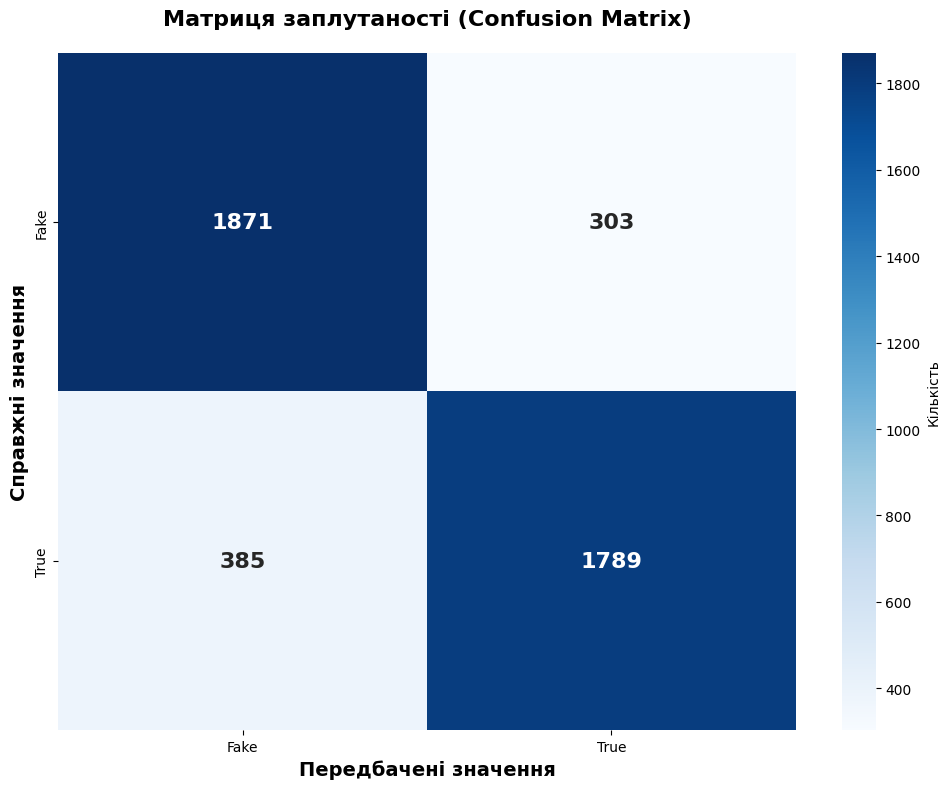


ДЕТАЛЬНА СТАТИСТИКА МАТРИЦІ ЗАПЛУТАНОСТІ
True Negatives (TN): 1871 - правильно визначені FAKE
False Positives (FP): 303 - помилково визначені як TRUE
False Negatives (FN): 385 - помилково визначені як FAKE
True Positives (TP): 1789 - правильно визначені TRUE


In [33]:
import seaborn as sns

cm = confusion_matrix(Y_test, X_test_prediction)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Fake', 'True'],
    yticklabels=['Fake', 'True'],
    cbar_kws={'label': 'Кількість'},
    annot_kws={'size': 16, 'weight': 'bold'}
)
plt.title('Матриця заплутаності (Confusion Matrix)', fontsize=16, weight='bold', pad=20)
plt.ylabel('Справжні значення', fontsize=14, weight='bold')
plt.xlabel('Передбачені значення', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ДЕТАЛЬНА СТАТИСТИКА МАТРИЦІ ЗАПЛУТАНОСТІ")
print("="*60)
print(f"True Negatives (TN): {cm[0][0]} - правильно визначені FAKE")
print(f"False Positives (FP): {cm[0][1]} - помилково визначені як TRUE")
print(f"False Negatives (FN): {cm[1][0]} - помилково визначені як FAKE")
print(f"True Positives (TP): {cm[1][1]} - правильно визначені TRUE")
print("="*60)

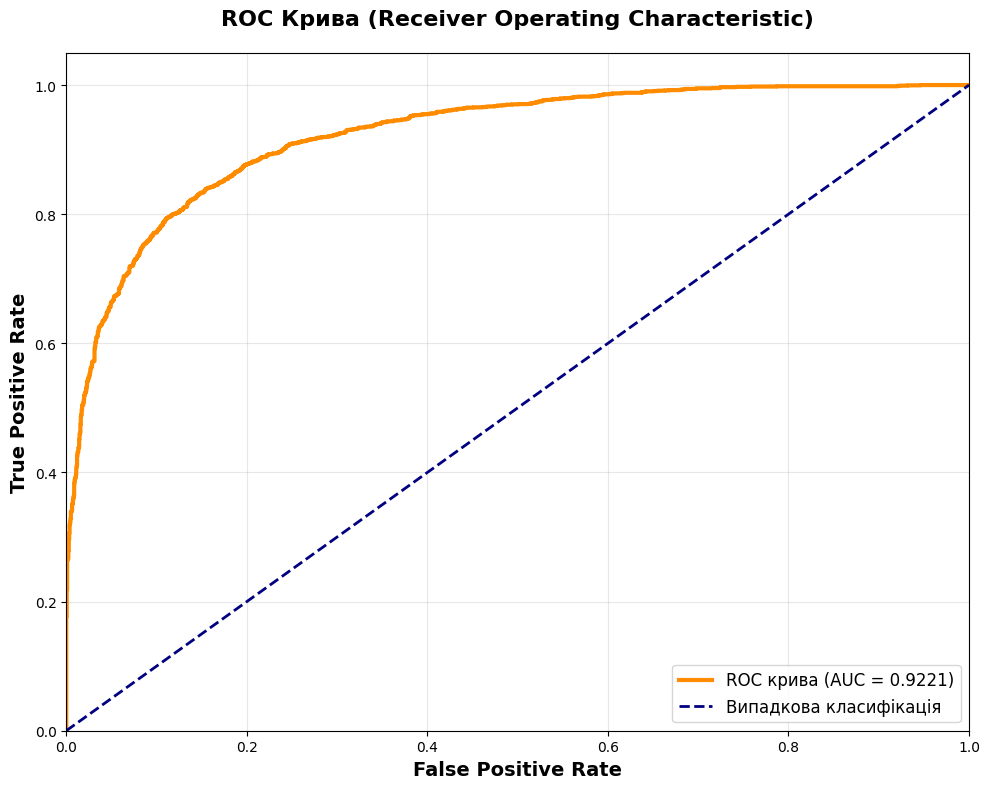


ROC AUC Score: 0.9221
Accuracy: 0.8418
F1-Score: 0.8387


In [34]:
Y_test_proba = model_detector.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(Y_test, Y_test_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC крива (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Випадкова класифікація')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, weight='bold')
plt.ylabel('True Positive Rate', fontsize=14, weight='bold')
plt.title('ROC Крива (Receiver Operating Characteristic)', fontsize=16, weight='bold', pad=20)
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC AUC Score: {roc_auc:.4f}")
print(f"Accuracy: {test_data_accuracy:.4f}")
print(f"F1-Score: {f1_score(Y_test, X_test_prediction):.4f}")

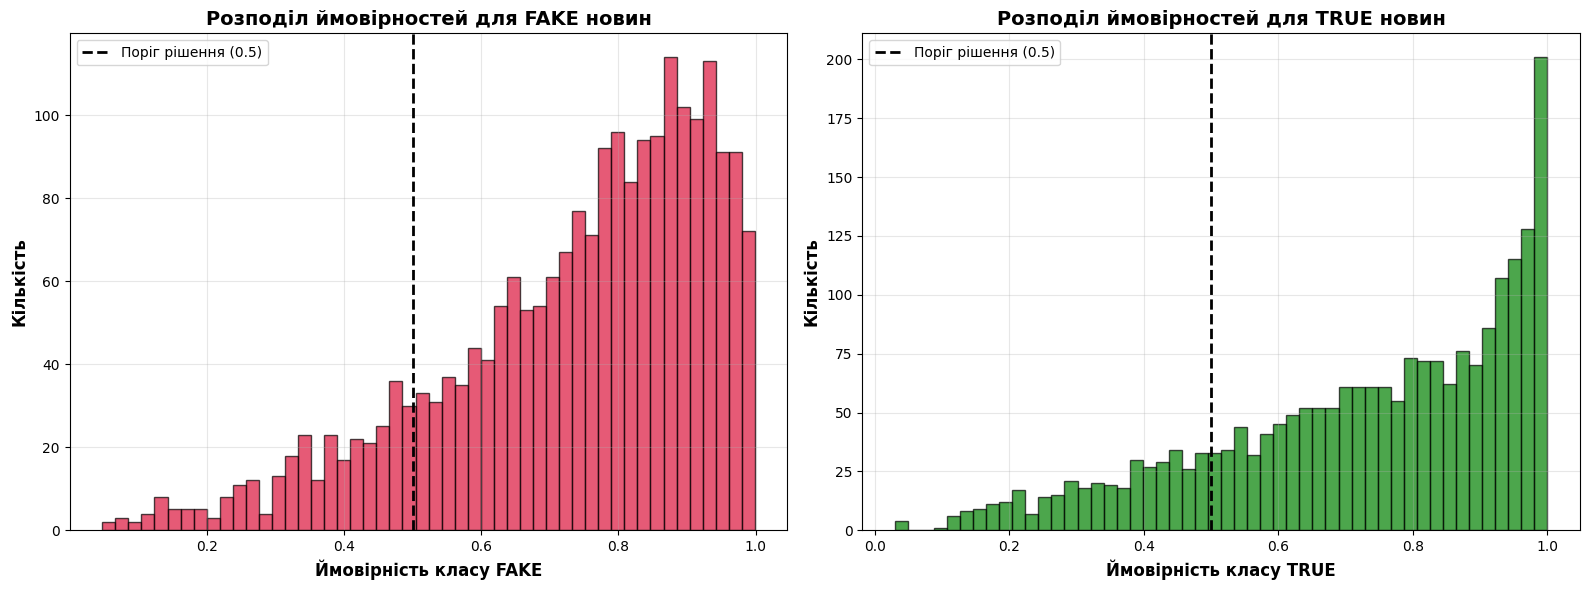

In [35]:
Y_test_proba_all = model_detector.predict_proba(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Графік 1: Розподіл ймовірностей для FAKE новин
fake_indices = Y_test == 0
axes[0].hist(Y_test_proba_all[fake_indices, 0], bins=50, color='crimson', alpha=0.7, edgecolor='black')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Поріг рішення (0.5)')
axes[0].set_xlabel('Ймовірність класу FAKE', fontsize=12, weight='bold')
axes[0].set_ylabel('Кількість', fontsize=12, weight='bold')
axes[0].set_title('Розподіл ймовірностей для FAKE новин', fontsize=14, weight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Графік 2: Розподіл ймовірностей для TRUE новин
true_indices = Y_test == 1
axes[1].hist(Y_test_proba_all[true_indices, 1], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Поріг рішення (0.5)')
axes[1].set_xlabel('Ймовірність класу TRUE', fontsize=12, weight='bold')
axes[1].set_ylabel('Кількість', fontsize=12, weight='bold')
axes[1].set_title('Розподіл ймовірностей для TRUE новин', fontsize=14, weight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2. Precision-Recall крива

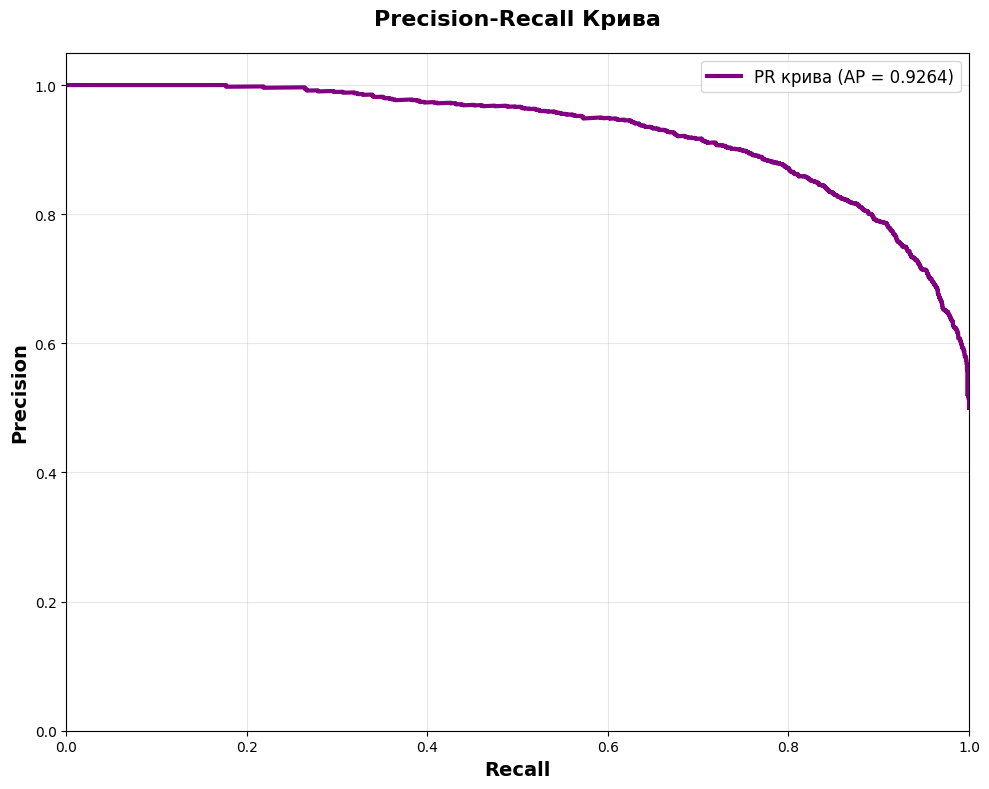


📊 Average Precision Score: 0.9264
   • Показує баланс між точністю та повнотою
   • Чим ближче до 1.0, тим краще


In [36]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds_pr = precision_recall_curve(Y_test, Y_test_proba)
avg_precision = average_precision_score(Y_test, Y_test_proba)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='purple', lw=3, label=f'PR крива (AP = {avg_precision:.4f})')
plt.xlabel('Recall', fontsize=14, weight='bold')
plt.ylabel('Precision', fontsize=14, weight='bold')
plt.title('Precision-Recall Крива', fontsize=16, weight='bold', pad=20)
plt.legend(loc="upper right", fontsize=12)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.show()

print(f"\n📊 Average Precision Score: {avg_precision:.4f}")
print(f"   • Показує баланс між точністю та повнотою")
print(f"   • Чим ближче до 1.0, тим краще")

### 3. Топ-20 найважливіших ознак (слів) для класифікації

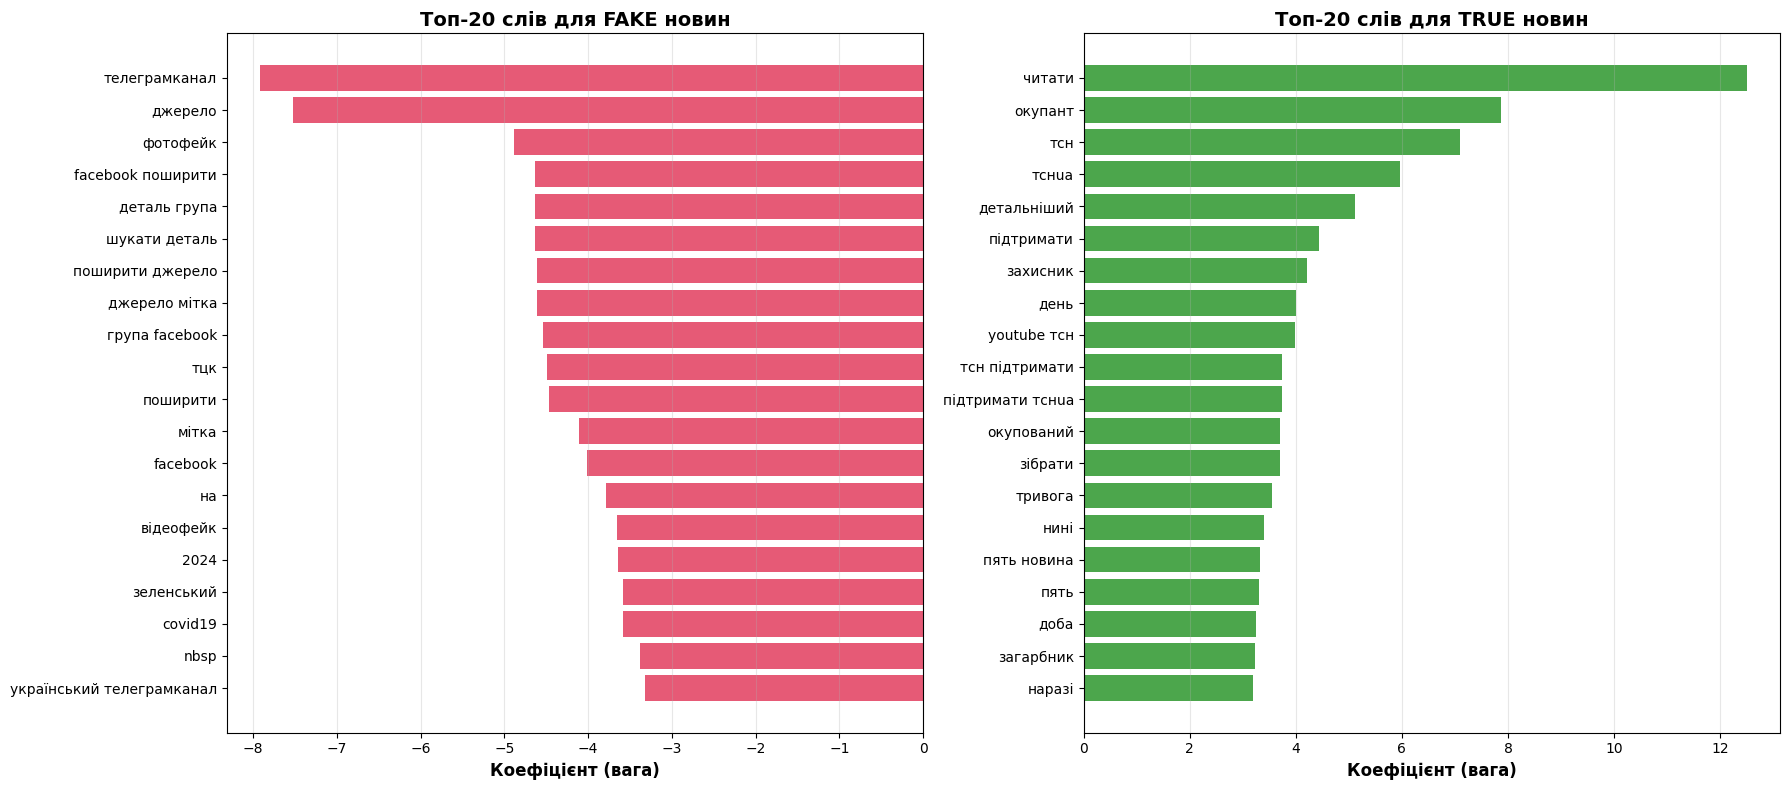

🔍 Ці слова (і n-грами) мають найбільший вплив на рішення моделі


In [37]:
feature_names = vectorizer.get_feature_names_out()
coefficients = model_detector.coef_[0]

# Топ-20 слів для FAKE новин (негативні коефіцієнти)
top_fake_indices = np.argsort(coefficients)[:20]
top_fake_words = [feature_names[i] for i in top_fake_indices]
top_fake_coefs = coefficients[top_fake_indices]

# Топ-20 слів для TRUE новин (позитивні коефіцієнти)
top_true_indices = np.argsort(coefficients)[-20:][::-1]
top_true_words = [feature_names[i] for i in top_true_indices]
top_true_coefs = coefficients[top_true_indices]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Графік для FAKE новин
axes[0].barh(range(20), top_fake_coefs, color='crimson', alpha=0.7)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top_fake_words)
axes[0].set_xlabel('Коефіцієнт (вага)', fontsize=12, weight='bold')
axes[0].set_title('Топ-20 слів для FAKE новин', fontsize=14, weight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Графік для TRUE новин
axes[1].barh(range(20), top_true_coefs, color='green', alpha=0.7)
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(top_true_words)
axes[1].set_xlabel('Коефіцієнт (вага)', fontsize=12, weight='bold')
axes[1].set_title('Топ-20 слів для TRUE новин', fontsize=14, weight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("🔍 Ці слова (і n-грами) мають найбільший вплив на рішення моделі")

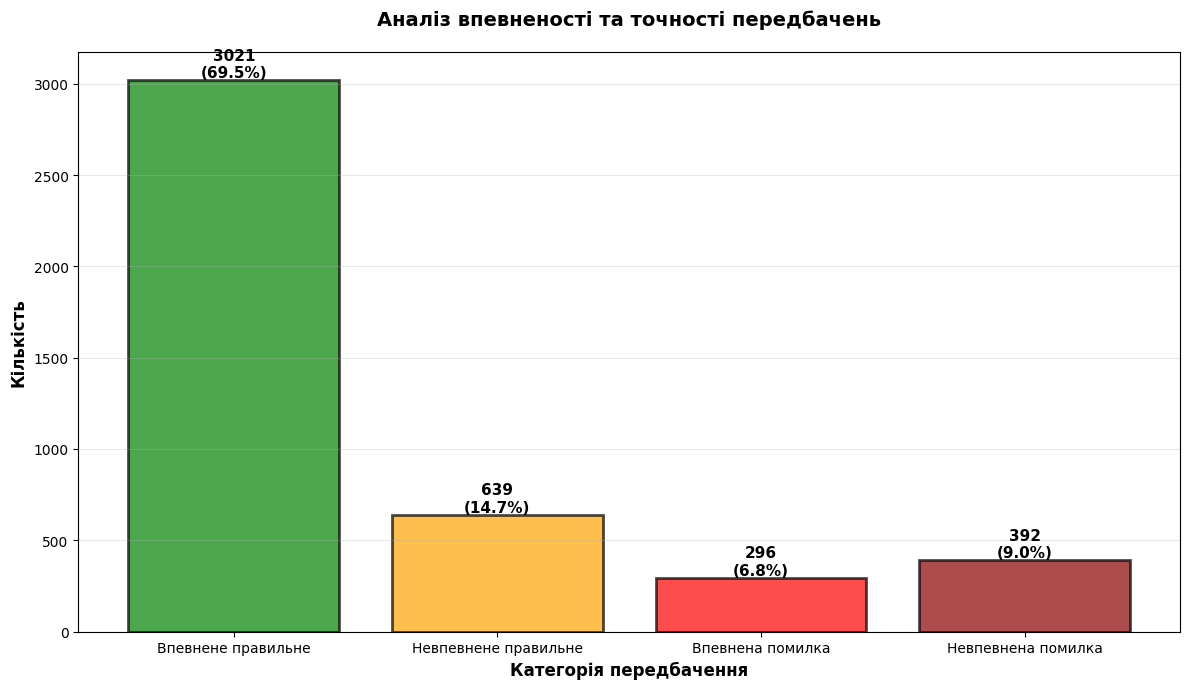

📊 СТАТИСТИКА ПЕРЕДБАЧЕНЬ:
Впевнене правильне       :  3021 (69.48%)
Невпевнене правильне     :   639 (14.70%)
Впевнена помилка         :   296 ( 6.81%)
Невпевнена помилка       :   392 ( 9.02%)


In [38]:
uncertainty_threshold = 0.15
max_proba = np.max(Y_test_proba_all, axis=1)
uncertain_mask = (max_proba >= 0.5) & (max_proba <= 0.5 + uncertainty_threshold)

correct_predictions = X_test_prediction == Y_test
errors = ~correct_predictions

categories = []
colors = []
for uncertain, error in zip(uncertain_mask, errors):
    if uncertain and error:
        categories.append('Невпевнена помилка')
        colors.append('darkred')
    elif uncertain and not error:
        categories.append('Невпевнене правильне')
        colors.append('orange')
    elif not uncertain and error:
        categories.append('Впевнена помилка')
        colors.append('red')
    else:
        categories.append('Впевнене правильне')
        colors.append('green')

unique_categories = ['Впевнене правильне', 'Невпевнене правильне', 
                     'Впевнена помилка', 'Невпевнена помилка']
counts = [categories.count(cat) for cat in unique_categories]
cat_colors = ['green', 'orange', 'red', 'darkred']

plt.figure(figsize=(12, 7))
bars = plt.bar(unique_categories, counts, color=cat_colors, alpha=0.7, edgecolor='black', linewidth=2)
plt.xlabel('Категорія передбачення', fontsize=12, weight='bold')
plt.ylabel('Кількість', fontsize=12, weight='bold')
plt.title('Аналіз впевненості та точності передбачень', fontsize=14, weight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Додаємо значення на стовпчики
for bar, count in zip(bars, counts):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{count}\n({count/len(Y_test)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, weight='bold')

plt.tight_layout()
plt.show()

print("="*60)
print("📊 СТАТИСТИКА ПЕРЕДБАЧЕНЬ:")
print("="*60)
for cat, count in zip(unique_categories, counts):
    print(f"{cat:25s}: {count:5d} ({count/len(Y_test)*100:5.2f}%)")
print("="*60)

In [39]:
input_news = "Компанія Apple анонсувала розробку нового смартфона, який заряджається виключно від звукових хвиль."

In [40]:
filtered_news = filtering(input_news)
input_text = lemmatize_text(filtered_news)
input_vector = vectorizer.transform([input_text])
prediction = model_detector.predict(input_vector)
prob = model_detector.predict_proba(input_vector)
input_text

'компанія apple анонсувати розробка нове смартфон заряджатися виключно звуковий хвиля'

In [41]:
def true_or_false(prob):
    if prob[0][1] > 0.5:
        label = "true"
        probability = prob[0][1]
    else:
        label = "false"
        probability = prob[0][0]
    return label, probability

In [42]:
label, probability = true_or_false(prob)
print(f"News is {label}, with probability {(probability * 100):.2f}%")

News is true, with probability 57.32%


In [43]:
import pickle
with open('fake_true_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('model_detector.pkl', 'wb') as f:
    pickle.dump(model_detector, f)